In [165]:
import pandas as pd

## Car Price Prediction Using Simple Linear Regression

Using `Present_Price` as input feature and `Selling_Price` as target.

In [166]:
df = pd.read_csv('car data.csv')

## Data Overview

Checking dataset size and quick records preview.

In [167]:
df.shape

(301, 9)

In [168]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [169]:
import matplotlib.pyplot as plt

## Exploratory Data Analysis (EDA)

Scatter plot to visualize the relationship between present and selling price.

Text(0, 0.5, 'selling price')

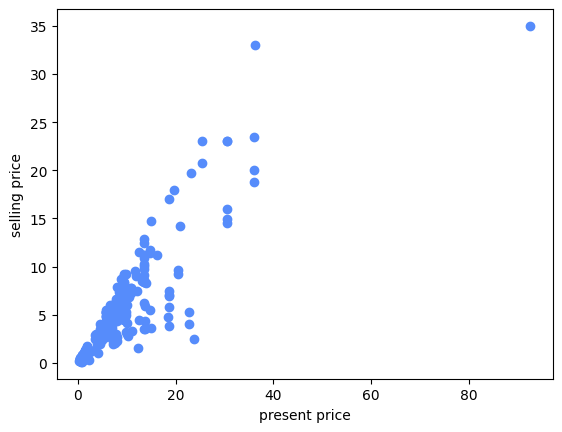

In [170]:
plt.scatter(df['Present_Price'], df['Selling_Price'])
plt.xlabel('present price')
plt.ylabel('selling price')

## Train-Test Split

Split into training and testing sets to evaluate the model on unseen data.

In [171]:
from sklearn.model_selection import train_test_split

In [172]:
x_train, x_test, y_train, y_test = train_test_split(df['Present_Price'], df['Selling_Price'], test_size=0.30,
                                                    random_state=42)

## Model Training

Fit a linear regression model on training data.

In [173]:
from sklearn.linear_model import LinearRegression

In [174]:
model = LinearRegression()

In [175]:
model.fit(x_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [176]:
model.coef_

array([0.49095052])

In [177]:
model.intercept_

np.float64(0.9374011823665436)

In [178]:
y_pred = model.predict(x_test.values.reshape(-1, 1))

## Evaluation

Plot regression line and compute MSE, MAE, and R2 score.

In [179]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Text(0, 0.5, 'selling price')

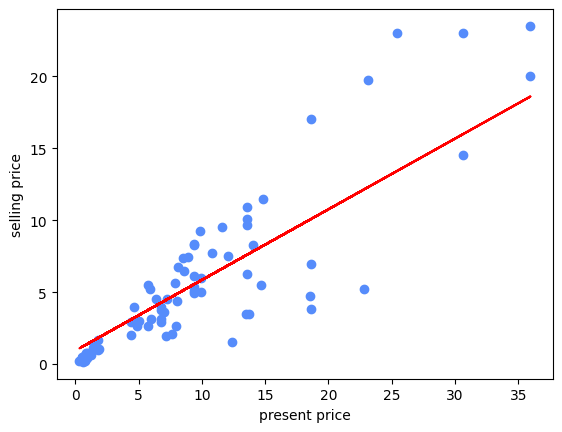

In [180]:
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel('present price')
plt.ylabel('selling price')

In [181]:
mean_squared_error(y_test, y_pred)

6.692646155634922

In [182]:
mean_absolute_error(y_test, y_pred)

1.751119268646896

In [183]:
r2_score(y_test, y_pred)

0.7649575398292181